# SECOM dataset ML Project
---

### Loading in the SECOM dataset

In [2]:
# Imports
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn import set_config
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from umap import UMAP
import warnings

In [3]:
# silencing nuissance warnings
warnings.filterwarnings("ignore")

In [4]:
# setting config for sklearn transforms to output pandas and not numpy arrays
set_config(transform_output="pandas")

In [5]:
# Pulling in the SECOM data and loading data into feature and label dataframes
secom = fetch_ucirepo(id=179)
df = pd.DataFrame(secom.data.original)
X = df.drop(columns=["class", "timestamp"])
y = df["class"]

print(X.shape)
print(y.shape)

(1567, 590)
(1567,)


---

### Exploratory Data Analysis (EDA)

In [6]:
# checking data types of features
X.dtypes.value_counts()

float64    590
Name: count, dtype: int64

In [7]:
# checking null counts and null percentage of features
feature_summary = pd.DataFrame({
    "null_counts": X.isna().sum(),
    "null_pct": round(X.isna().mean()*100, 2)
}).sort_values("null_pct", ascending=False)

print(feature_summary.head(50))

               null_counts  null_pct
Attribute 293         1429     91.19
Attribute 294         1429     91.19
Attribute 159         1429     91.19
Attribute 158         1429     91.19
Attribute 493         1341     85.58
Attribute 86          1341     85.58
Attribute 359         1341     85.58
Attribute 221         1341     85.58
Attribute 245         1018     64.96
Attribute 518         1018     64.96
Attribute 110         1018     64.96
Attribute 247         1018     64.96
Attribute 384         1018     64.96
Attribute 383         1018     64.96
Attribute 385         1018     64.96
Attribute 246         1018     64.96
Attribute 112         1018     64.96
Attribute 111         1018     64.96
Attribute 517         1018     64.96
Attribute 519         1018     64.96
Attribute 581          949     60.56
Attribute 579          949     60.56
Attribute 580          949     60.56
Attribute 582          949     60.56
Attribute 74           794     50.67
Attribute 346          794     50.67
A

In [8]:
# checking class balance and null counts
label_summary = pd.DataFrame({
    "counts": y.value_counts(),
    "null_counts": y.isna().sum(),
    "pct": round(y.value_counts()/len(y)*100, 2),    
})

print(label_summary)

       counts  null_counts    pct
class                            
-1       1463            0  93.36
 1        104            0   6.64


In [9]:
# Recoding passes from -1 to 0 for ease of analysis later
y = y.replace(-1, 0)

---

In [10]:
# filtering out features with null percentage above threshold
threshold = 90 # null pct threshold

null_cols = X.columns[X.isna().mean()*100 > threshold]
X_filtered = X.drop(columns=null_cols)
X_filtered.shape

(1567, 586)

In [11]:
# Fill remaining NaN values with median
X_filtered = SimpleImputer(strategy='median').fit_transform(X_filtered)
X_filtered.isna().sum().sort_values(ascending=False).head()

Attribute 1    0
Attribute 2    0
Attribute 3    0
Attribute 4    0
Attribute 5    0
dtype: int64

In [12]:
# Remove constant variance terms
zero_var_cols = X_filtered.columns[X_filtered.var() == 0]
X_filtered = X_filtered.drop(columns=zero_var_cols)
X_filtered.shape

(1567, 470)

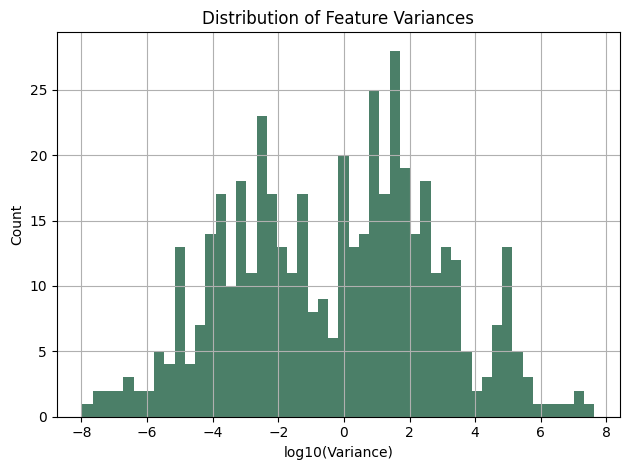

In [ ]:
# Checking variance threshold to see if we have an obvious cutoff point
variances = X_filtered.var()

plt.hist(np.log10(variances), bins=50, color='#4B7F68')
plt.xlabel("log10(Variance)")
plt.ylabel("Count")
plt.title("Distribution of Feature Variances")
plt.grid()
plt.tight_layout()
# plt.savefig("../figures/variance_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

___

### Before moving any further with feature selection, looking at unsupervised dimensionality reduction techniques: beginning with PCA

In [14]:
# Running PCA
X_scaled = StandardScaler().fit_transform(X_filtered)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

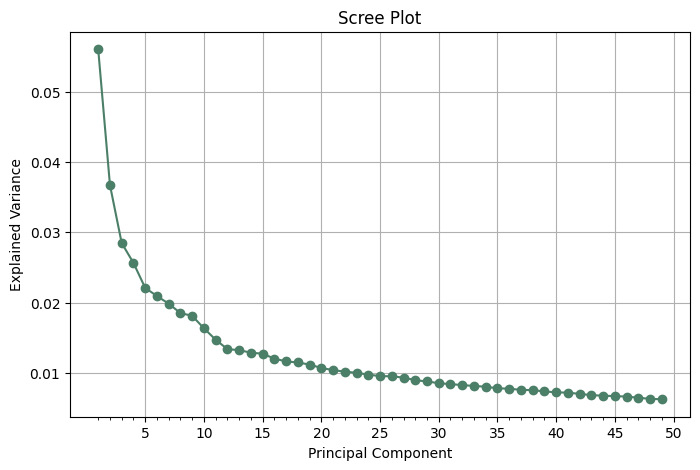

In [15]:
# Plotting the Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 50), pca.explained_variance_ratio_[:49], color='#4B7F68', marker='o')
plt.xlabel("Principal Component")
plt.xticks(ticks=range(5, 51, 5))
plt.xticks(ticks=range(1, 50), minor=True)
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

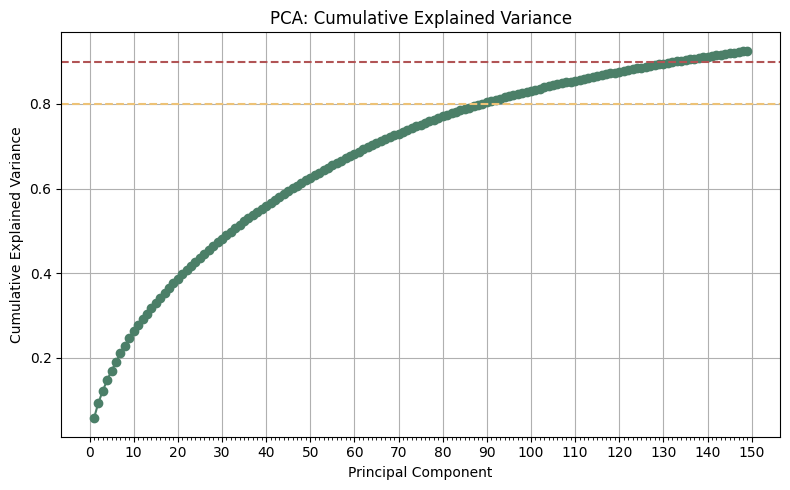

In [ ]:
# Plotting cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 150), cum_var[:149], color='#4B7F68', marker='o')
plt.xlabel("Principal Component")
plt.xticks(ticks=range(0, 151, 10))
plt.xticks(ticks=range(1, 150), minor=True)
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.grid(True)
plt.axhline(0.8, ls='--', color = '#EDC276')
plt.axhline(0.9, ls='--', color = '#B15455')
plt.tight_layout()
# plt.savefig("../figures/pca_cumulative_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

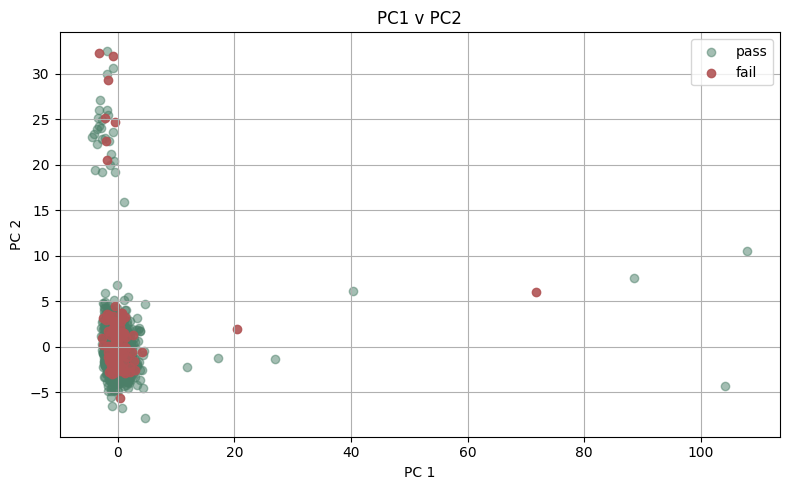

In [ ]:
# Plotting PC1 v PC2
plt.figure(figsize=(8,5))
plt.scatter(X_pca.loc[y==0, "pca0"], X_pca.loc[y==0, "pca1"], alpha=0.5, label="pass", color='#4B7F68')
plt.scatter(X_pca.loc[y==1, "pca0"], X_pca.loc[y==1, "pca1"], alpha=0.9, label="fail", color='#B15455')
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PC1 v PC2")
plt.grid(True)
plt.legend()
plt.tight_layout()
# plt.savefig("../figures/pca_pc1_pc2_projection.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# Calculating PCA loadings matrix
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns= [f"PC{i+1}" for i in range(pca.n_components_)]
)

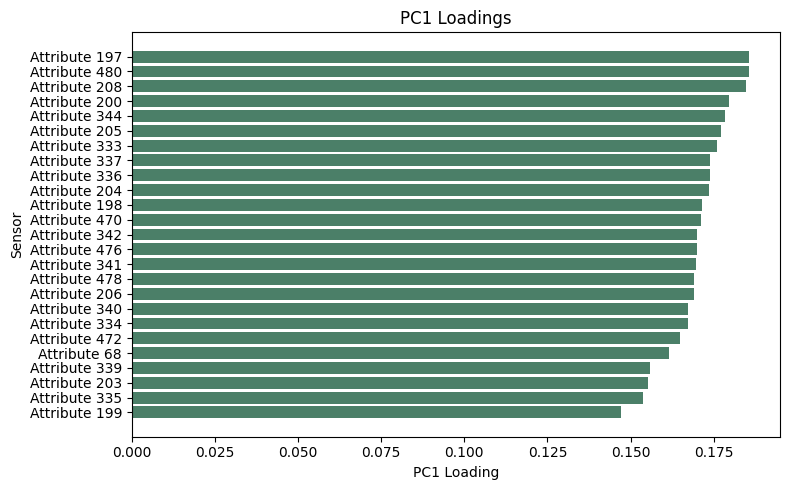

In [ ]:
# Plotting top contributors to PC1 loadings
top_sorted = loadings["PC1"].abs().sort_values(ascending=False).head(25)
top_plot = top_sorted.sort_values()
plt.figure(figsize=(8,5))
plt.barh(top_plot.index, top_plot, color='#4B7F68')
plt.xlabel("PC1 Loading")
plt.ylabel("Sensor")
plt.title("PC1 Loadings")
plt.tight_layout()
#plt.savefig("../figures/pca_pc1_loadings.png", dpi=300, bbox_inches="tight")
plt.show()

#### Remarks: PCA does not show dominant lower dimensional modes to be xisting in the data.  Many PCs needed to explain 80% of the variance and loadings seem similar amongst sensors for PC1.

Next step: Check PLS latent variables if any signal can be teased out from the labels.

In [20]:
# PLS
pls = PLSRegression(n_components=2)
X_pls, y_pls = pls.fit_transform(X_scaled, y)
X_pls.columns = ["LV1", "LV2"]

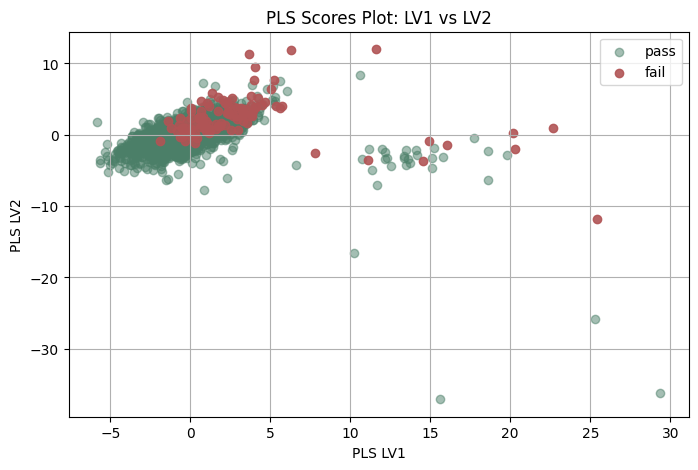

In [21]:
# PLS LV1 v LV2 plot

plt.figure(figsize=(8,5))

plt.scatter(
    X_pls.loc[y == 0, "LV1"],
    X_pls.loc[y == 0, "LV2"],
    alpha=0.5,
    label="pass",
    color="#4B7F68"
)

plt.scatter(
    X_pls.loc[y == 1, "LV1"],
    X_pls.loc[y == 1, "LV2"],
    alpha=0.9,
    label="fail",
    color="#B15455"
)

plt.xlabel("PLS LV1")
plt.ylabel("PLS LV2")
plt.title("PLS Scores Plot: LV1 vs LV2")
plt.legend()
plt.grid(True)
plt.show()

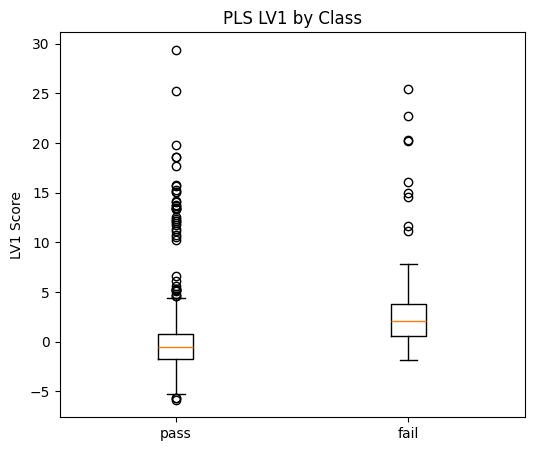

In [22]:
# LV1 vs y plot

plt.figure(figsize=(6,5))

plt.boxplot(
    [
        X_pls.loc[y==0, "LV1"],
        X_pls.loc[y==1, "LV1"]
    ],
    tick_labels=["pass", "fail"]
)

plt.ylabel("LV1 Score")
plt.title("PLS LV1 by Class")
plt.show()

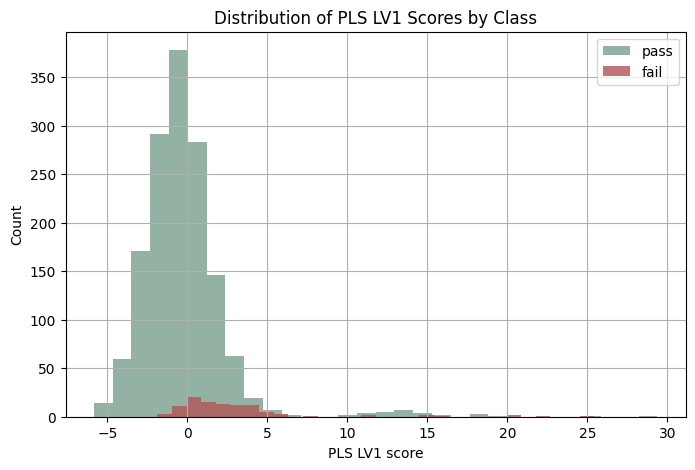

In [23]:
# Plot LV1 by class histograms
plt.figure(figsize=(8,5))

plt.hist(
    X_pls.loc[y == 0, "LV1"],
    bins=30,
    alpha=0.6,
    label="pass",
    color="#4B7F68"
)

plt.hist(
    X_pls.loc[y == 1, "LV1"],
    bins=30,
    alpha=0.8,
    label="fail",
    color="#B15455"
)

plt.xlabel("PLS LV1 score")
plt.ylabel("Count")
plt.title("Distribution of PLS LV1 Scores by Class")
plt.legend()
plt.grid(True)
plt.show()

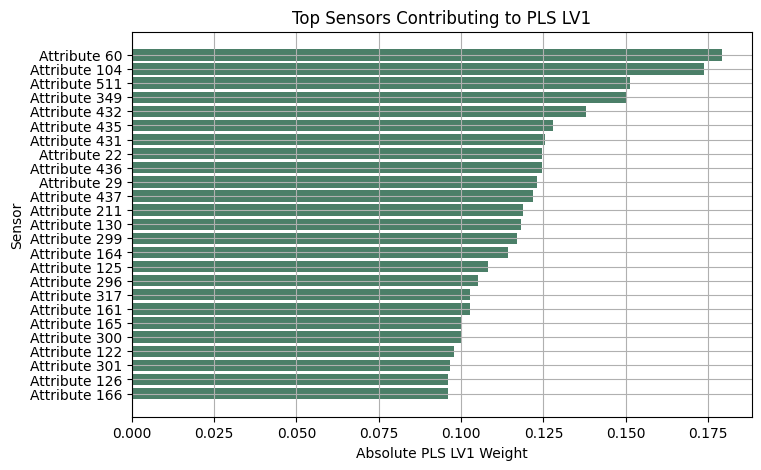

In [24]:
# Check PLS LV1 loading top contributors
weights = pd.DataFrame(
    pls.x_weights_,
    index=X_scaled.columns,
    columns=["LV1", "LV2"]
)

top = weights["LV1"].abs().sort_values(ascending=False).head(25)

plt.figure(figsize=(8,5))
plt.barh(
    top.sort_values().index,
    top.sort_values(),
    color="#4B7F68"
)
plt.xlabel("Absolute PLS LV1 Weight")
plt.ylabel("Sensor")
plt.title("Top Sensors Contributing to PLS LV1")
plt.grid(True)
plt.show()

#### Remarks: PLS is slightly better than PCA in showing class separation.  We can see the boxplots of LV1 by class have some delta in medians and the histogram plot shows a shifted LV1 score on passes v fails

Next step: run UMAP to visualize potential non-linear patterns

In [25]:
# Run umap

umap_model = UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
X_umap = pd.DataFrame(
    X_umap,
    index = X_scaled.index,
    columns = ["UMAP1", "UMAP2"]
)

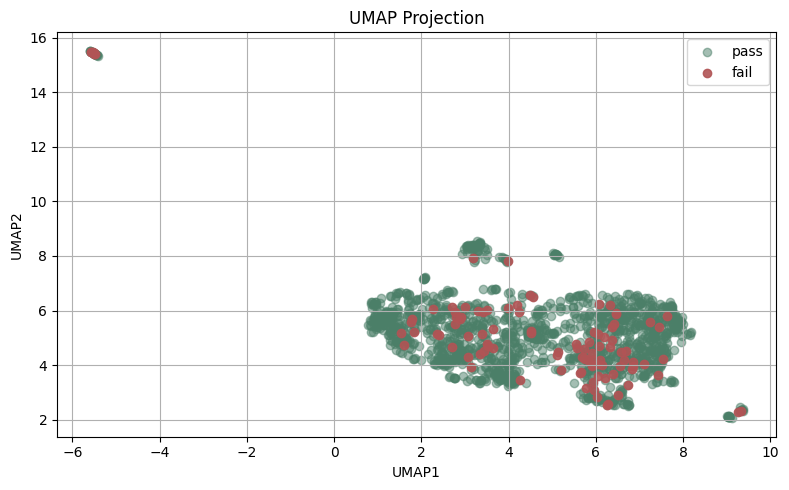

In [ ]:
# Plotting umap result
plt.figure(figsize=(8,5))

plt.scatter(
    X_umap.loc[y==0, "UMAP1"],
    X_umap.loc[y==0, "UMAP2"],
    alpha=0.5,
    label="pass",
    color="#4B7F68"
)

plt.scatter(
    X_umap.loc[y==1, "UMAP1"],
    X_umap.loc[y==1, "UMAP2"],
    alpha=0.9,
    label="fail",
    color="#B15455"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Projection")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("../figures/umap_projection.png", dpi=300, bbox_inches="tight")
plt.show()

#### Remarks: UMAP not showing clear separation for pass/fail classes.

Next step: Visualize t-SNE as next EDA to visualize any structure

In [27]:
# Running t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
X_tsne.columns = ["TSNE1", "TSNE2"]

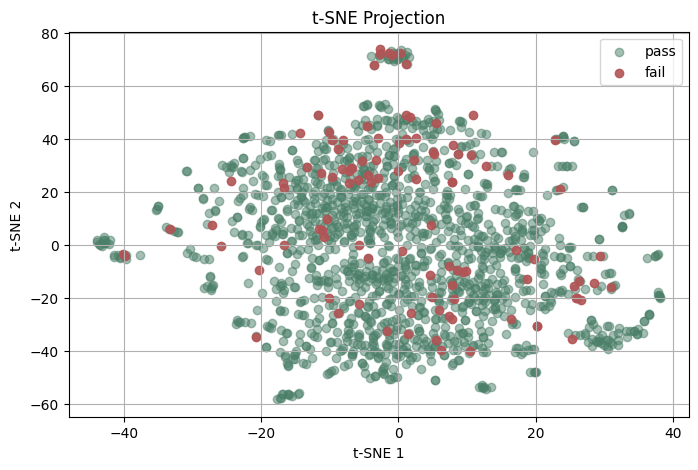

In [28]:
# Plotting TSNE

plt.figure(figsize=(8,5))

plt.scatter(
    X_tsne.loc[y==0, "TSNE1"],
    X_tsne.loc[y==0, "TSNE2"],
    alpha=0.5,
    label="pass",
    color="#4B7F68"
)

plt.scatter(
    X_tsne.loc[y==1, "TSNE1"],
    X_tsne.loc[y==1, "TSNE2"],
    alpha=0.9,
    label="fail",
    color="#B15455"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection")
plt.legend()
plt.grid(True)
plt.show()

#### Remarks: T-SNE also not uncovering any lower dimensional separation between classes.

Next step: Run kernel PCA to unconver any hidden nonlinear manifolds.

___

In [29]:
# Running kernel PCA
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.01,
    random_state=42
)

X_kpca = kpca.fit_transform(X_scaled)
X_kpca.columns = ["kPC1", "kPC2"]

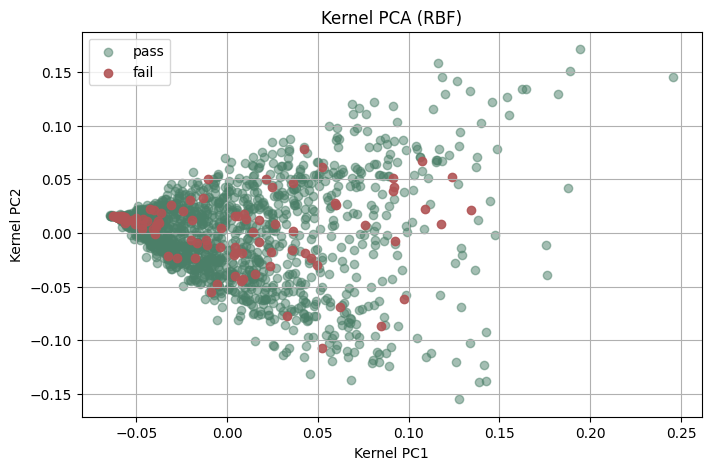

In [30]:
# Plotting kernel PCA
plt.figure(figsize=(8,5))

plt.scatter(
    X_kpca.loc[y==0, "kPC1"],
    X_kpca.loc[y==0, "kPC2"],
    alpha=0.5,
    label="pass",
    color="#4B7F68"
)

plt.scatter(
    X_kpca.loc[y==1, "kPC1"],
    X_kpca.loc[y==1, "kPC2"],
    alpha=0.9,
    label="fail",
    color="#B15455"
)

plt.xlabel("Kernel PC1")
plt.ylabel("Kernel PC2")
plt.title("Kernel PCA (RBF)")
plt.legend()
plt.grid(True)
plt.show()

#### Remarks: kPCA also not separating out classes.

Next step: Run Gaussian Mixture Model and plot on UMAP coordinates to identify any further clues to data structure.

In [31]:
# Run Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

clusters = gmm.fit_predict(X_scaled)

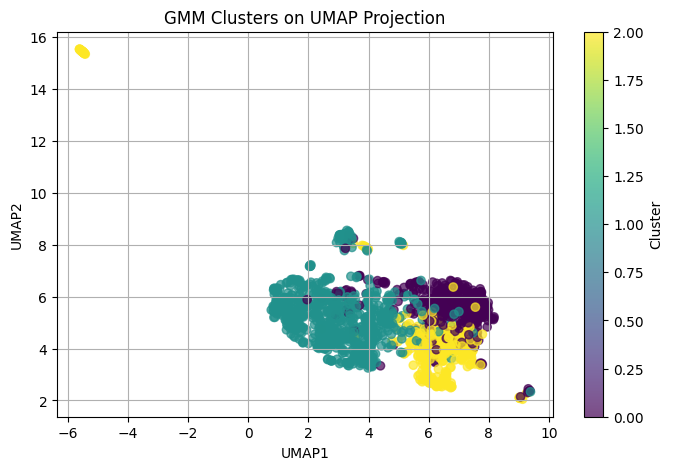

In [32]:
# Plot Gaussian Mixture Model on UMAP coordinates

plt.figure(figsize=(8,5))

plt.scatter(
    X_umap["UMAP1"],
    X_umap["UMAP2"],
    c=clusters,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("GMM Clusters on UMAP Projection")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [33]:
# Looking at clusters and their class alignments
pd.crosstab(clusters, y, normalize="index")

class,0,1
row_0,,
0,0.951031,0.048969
1,0.953283,0.046717
2,0.875969,0.124031


### Unsupervised dimensionality reduction conclusions
Multiple dimensionality-reduction methods (PCA, Kernel PCA, UMAP, t-SNE) did not reveal distinct failure clusters. PLS identified modest class-related structure, indicating some predictive signal exists. Gaussian Mixture Modeling revealed process regimes with differing failure rates, including one cluster with approximately twice the baseline failure rate. These results suggest failures are not a separate population but may occur with higher probability within certain operating regimes.

___

### Sensor level analysis
Checking some of the top sensors that came from the above analyses

In [34]:
# top sensors
top_sensors = [
    "Attribute 60",
    "Attribute 104",
    "Attribute 511",
    "Attribute 349",
    "Attribute 432",
    "Attribute 435",
    "Attribute 431",
	"Attribute 22",
	"Attribute 197",
	"Attribute 480",
]

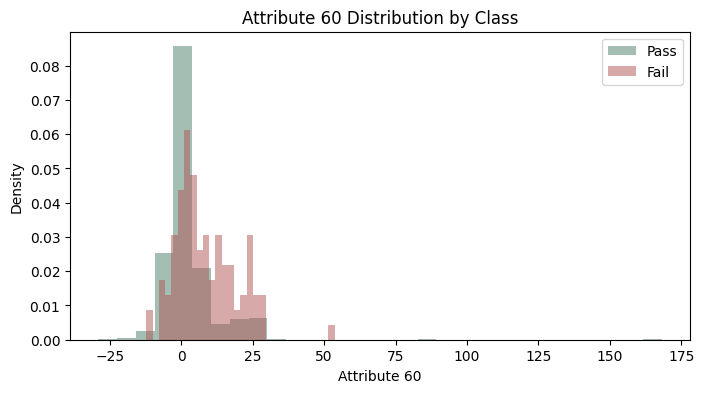

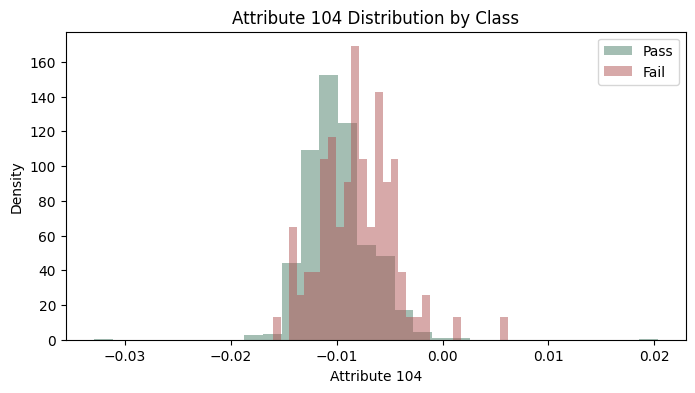

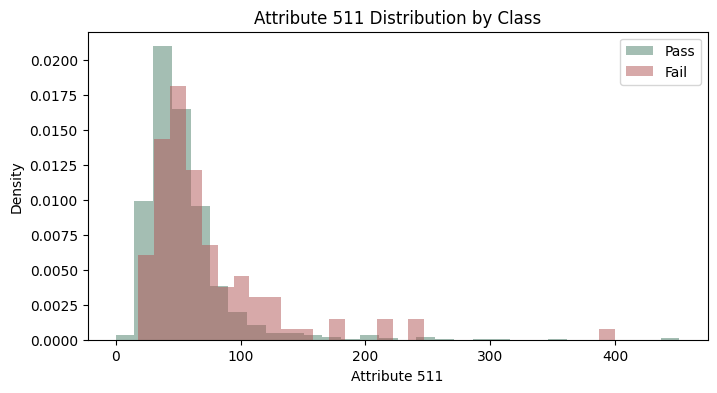

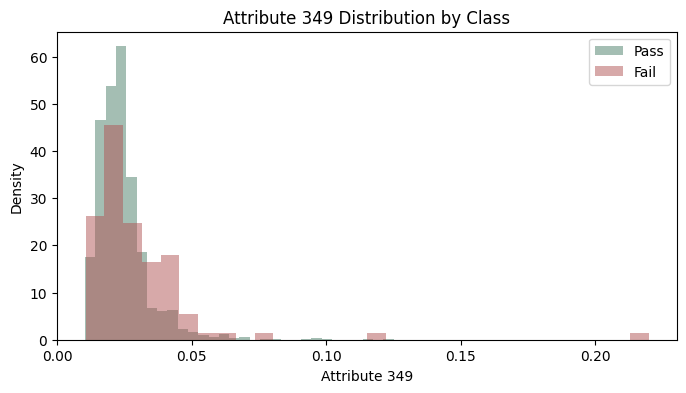

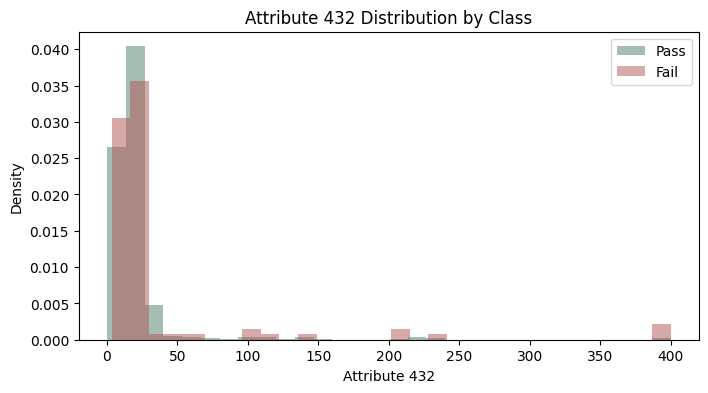

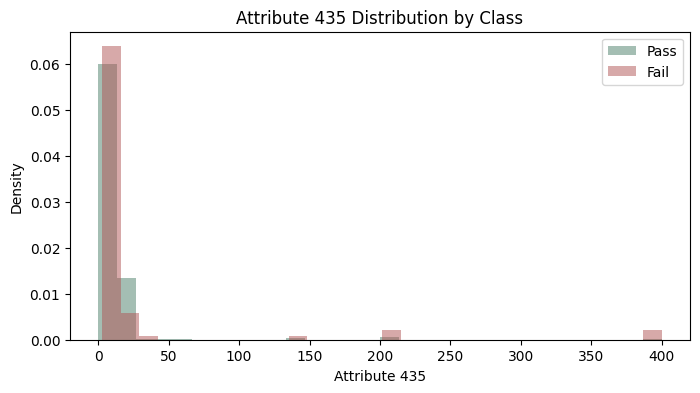

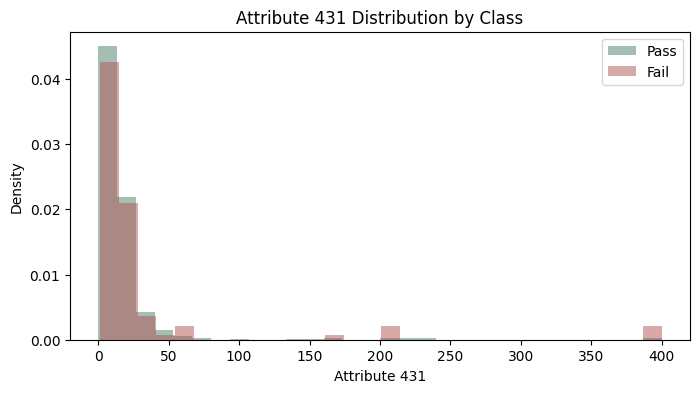

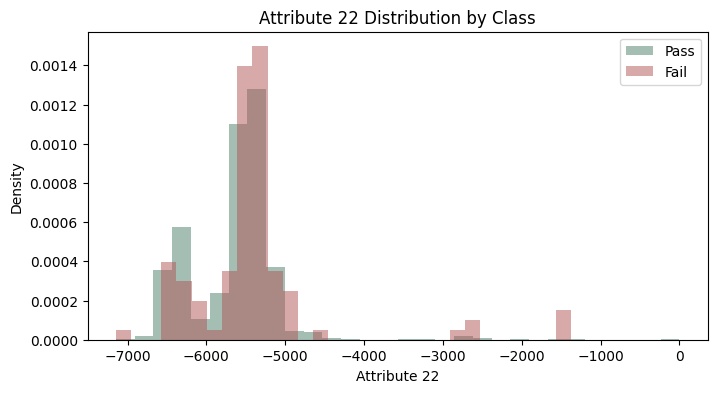

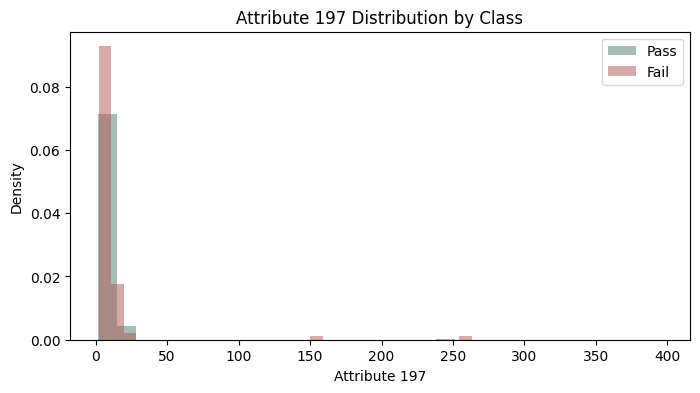

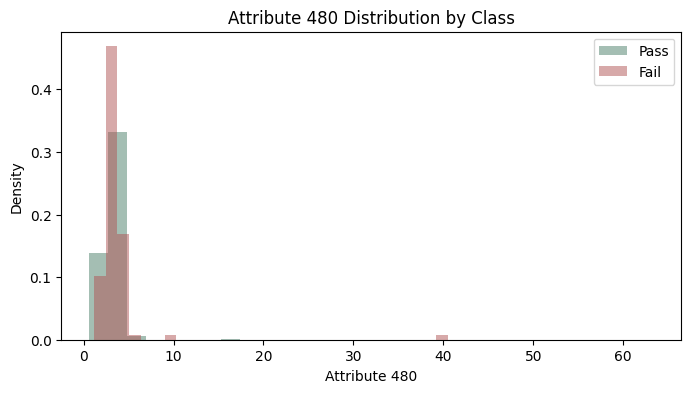

In [35]:
# Plotting histograms sensors
for sensor in top_sensors:
    plt.figure(figsize=(8, 4))

    plt.hist(
        X_filtered.loc[y == 0, sensor],
        bins=30,
        alpha=0.5,
        label="Pass",
        density=True,
        color="#4B7F68"
    )

    plt.hist(
        X_filtered.loc[y == 1, sensor],
        bins=30,
        alpha=0.5,
        label="Fail",
        density=True,
        color="#B15455"
    )

    plt.title(f"{sensor} Distribution by Class")
    plt.xlabel(sensor)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

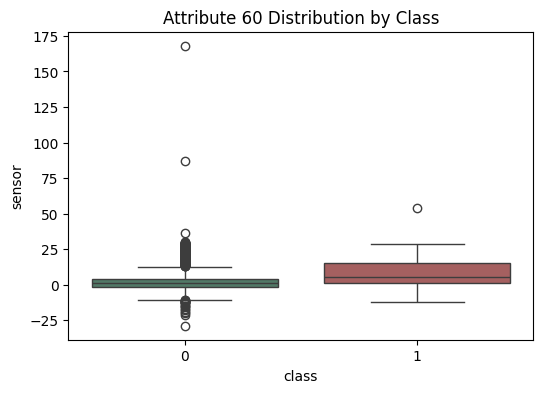

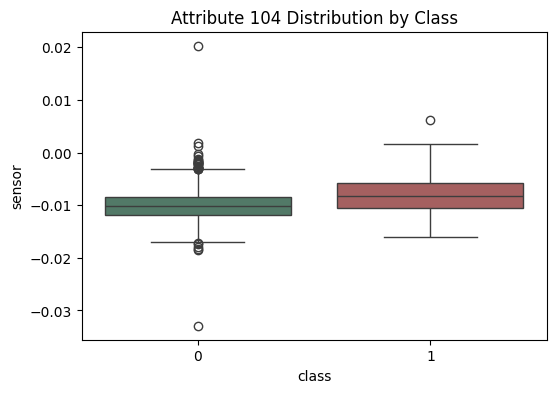

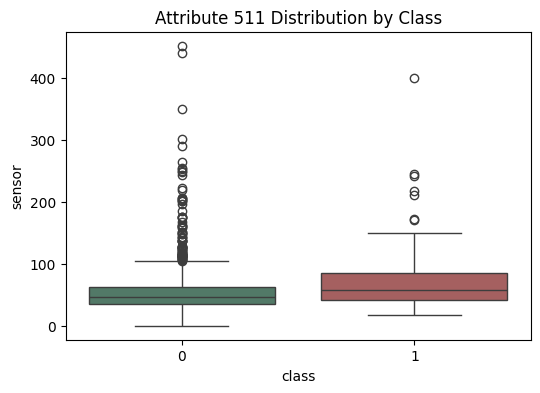

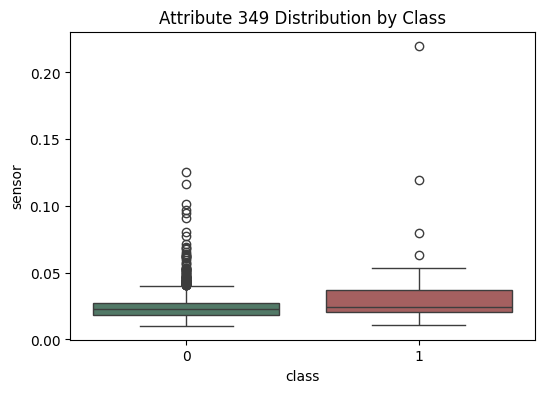

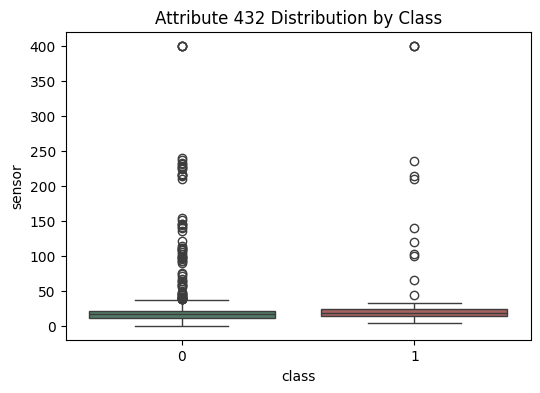

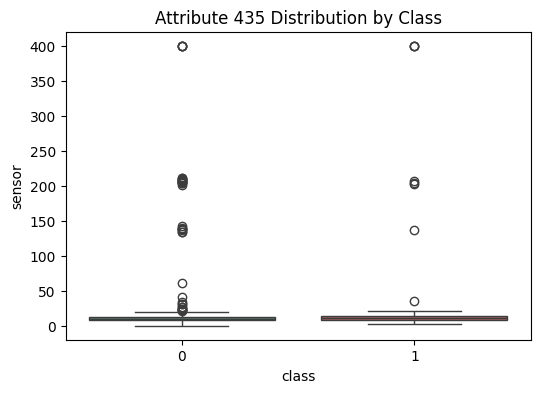

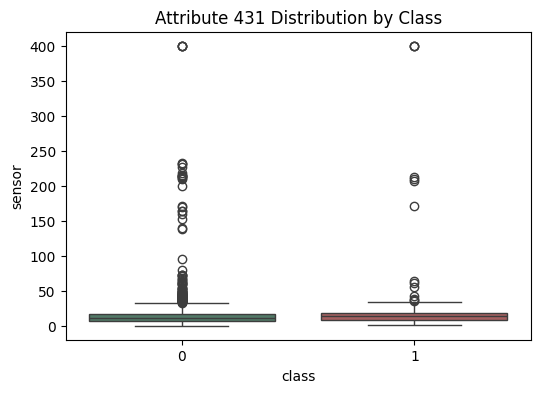

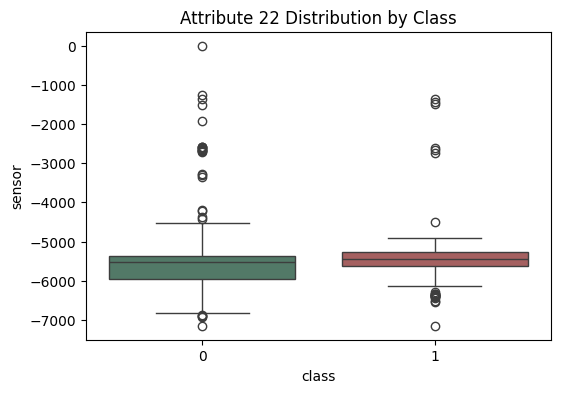

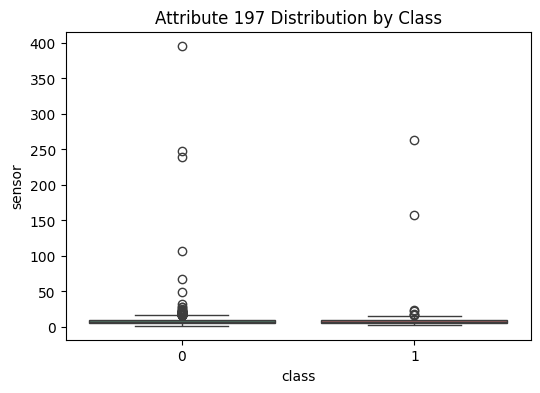

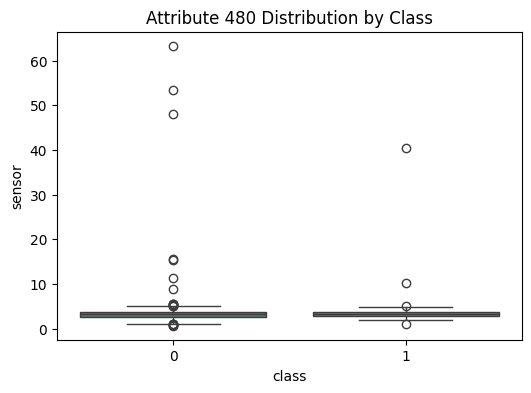

In [36]:
# Create boxplots of sensors
for sensor in top_sensors:

    plot_df = pd.DataFrame({
        "sensor": X_filtered[sensor],
        "class": y
    })

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=plot_df,
        x="class",
        y="sensor",
        hue="class",
        palette={
            0: "#4B7F68",   # Pass
            1: "#B15455"    # Fail
        },
        legend=False
    )

    plt.title(f"{sensor} Distribution by Class")
    plt.show()

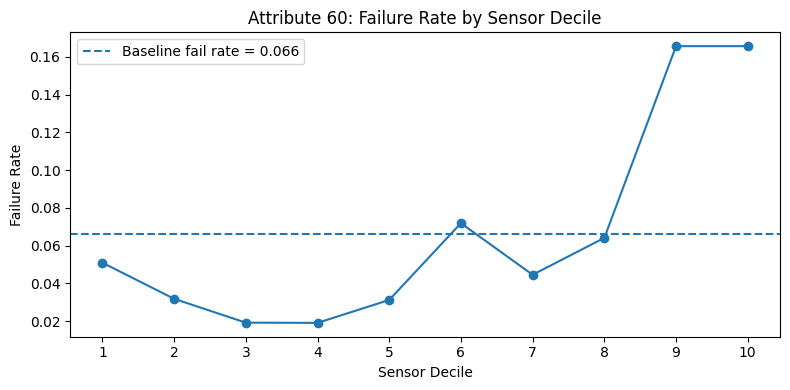

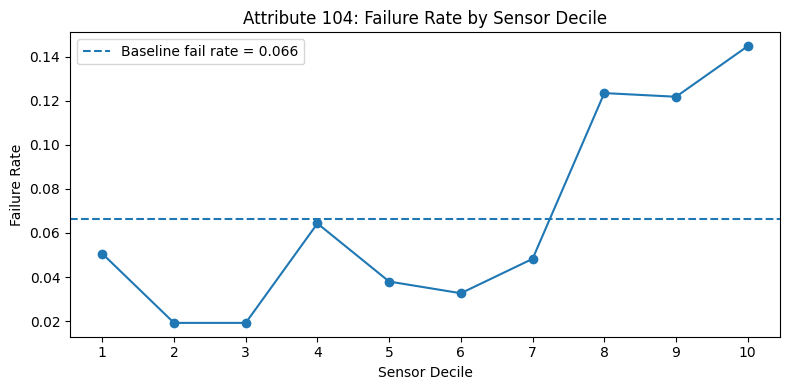

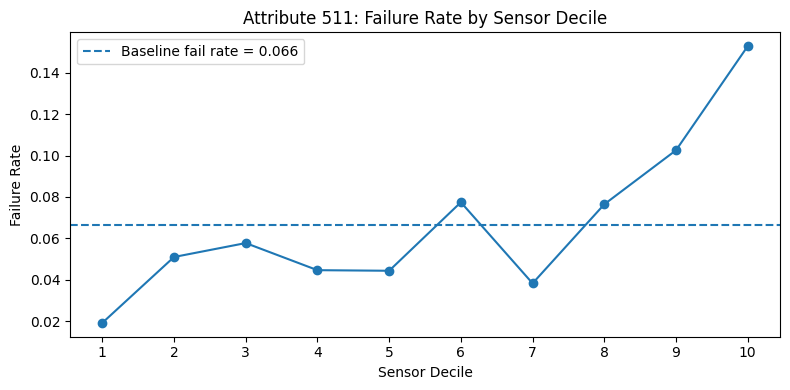

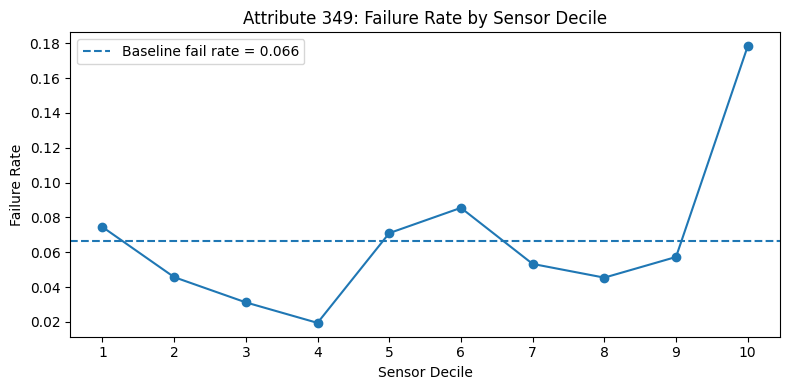

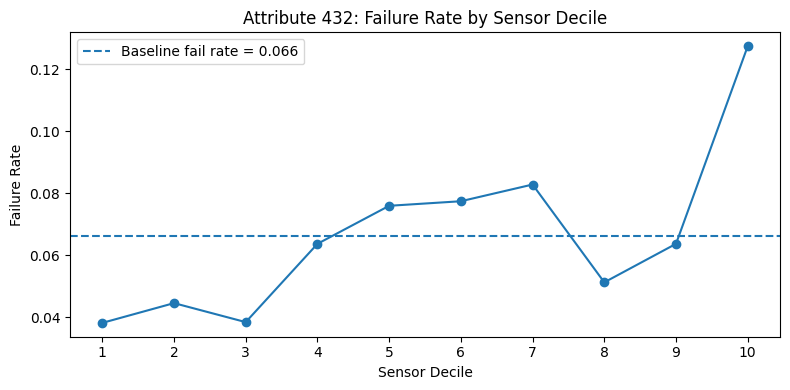

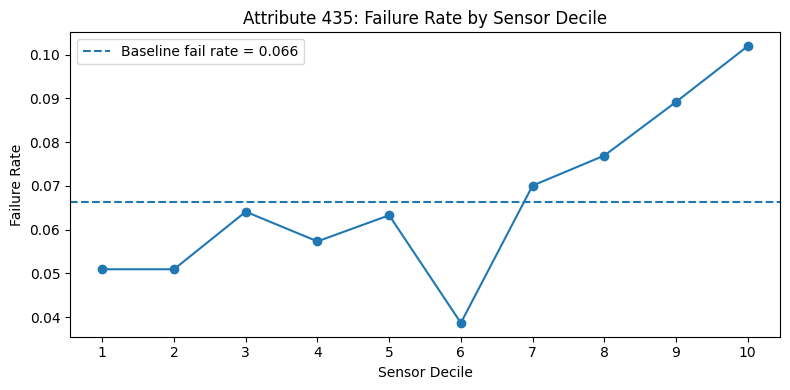

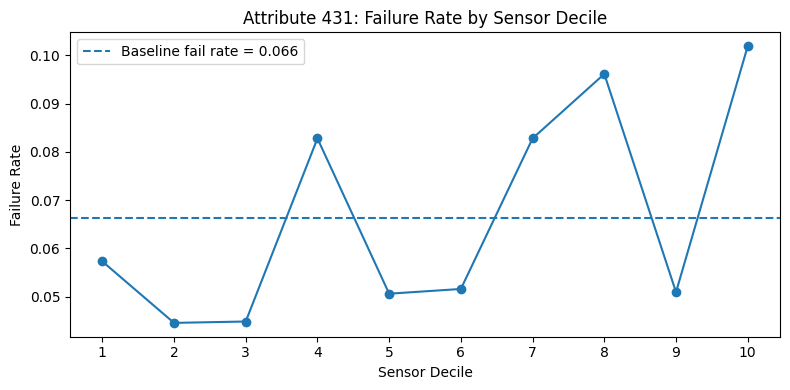

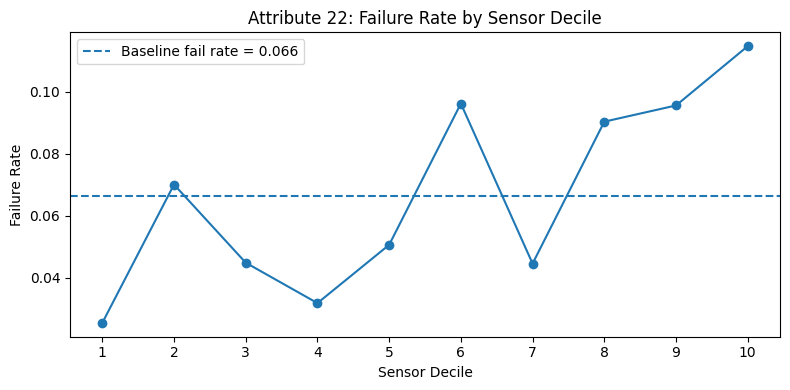

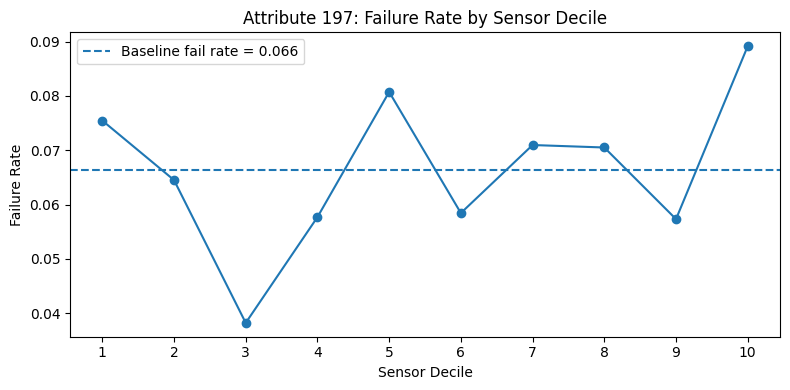

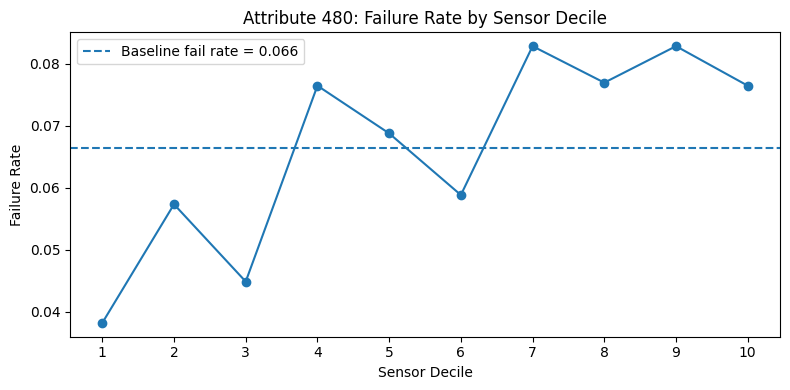

,sensor,max_failure_rate,risk_multiplier
0,Attribute 349,17.83,2.7
1,Attribute 60,16.56,2.5
2,Attribute 511,15.29,2.3
3,Attribute 104,14.47,2.2
4,Attribute 432,12.74,1.9
5,Attribute 22,11.46,1.7
6,Attribute 435,10.19,1.5
7,Attribute 431,10.19,1.5
8,Attribute 197,8.92,1.3
9,Attribute 480,8.28,1.2


In [ ]:
# Failure rate by sensor decile

top_sensor_summary = []

for sensor in top_sensors:

    tmp = pd.DataFrame({
        "sensor_value": X_filtered[sensor],
        "fail": y
    }).dropna()

    tmp["decile"] = pd.qcut(
        tmp["sensor_value"],
        q=10,
        duplicates="drop"
    )

    decile_summary = (
        tmp.groupby("decile", observed=True)
           .agg(
               n=("fail", "size"),
               failures=("fail", "sum"),
               failure_rate=("fail", "mean"),
               sensor_min=("sensor_value", "min"),
               sensor_max=("sensor_value", "max")
           )
           .reset_index()
    )


    top_sensor_summary.append({
        "sensor": f"{sensor}",
        "max_failure_rate": round(decile_summary["failure_rate"].max()*100, 2),
        "risk_multiplier": round(decile_summary["failure_rate"].max()/y.mean(),1)
    })


    plt.figure(figsize=(8, 4))

    plt.plot(
        range(1, len(decile_summary) + 1),
        decile_summary["failure_rate"],
        marker="o"
    )

    plt.axhline(
        y=y.mean(),
        linestyle="--",
        label=f"Baseline fail rate = {y.mean():.3f}"
    )

    plt.title(f"{sensor}: Failure Rate by Sensor Decile")
    plt.xlabel("Sensor Decile")
    plt.ylabel("Failure Rate")
    plt.xticks(range(1, len(decile_summary) + 1))
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f"../figures/failure_rate_decile_{sensor.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

top_sensor_summary_df = pd.DataFrame(top_sensor_summary)
top_sensor_summary_df.sort_values("risk_multiplier", ascending=False).reset_index(drop=True)

In [38]:
# Characterize GMM clusters using top sensors

cluster_df = X_scaled[top_sensors].copy()
cluster_df["cluster"] = clusters
cluster_df["fail"] = y

cluster_summary = (
    cluster_df.groupby("cluster")
              .agg(
                  n=("fail", "size"),
                  failures=("fail", "sum"),
                  failure_rate=("fail", "mean")
              )
)

display(cluster_summary)

,n,failures,failure_rate
cluster,,,
0,388,19,0.048969
1,792,37,0.046717
2,387,48,0.124031


In [39]:
# Calculating the median of each sensor inside each cluster
cluster_medians = (
    cluster_df.groupby("cluster")[top_sensors]
              .median()
)

display(cluster_medians)

,Attribute 60,Attribute 104,Attribute 511,Attribute 349,Attribute 432,Attribute 435,Attribute 431,Attribute 22,Attribute 197,Attribute 480
cluster,,,,,,,,,,
0,-0.201908,-0.068764,-0.179079,-0.193151,-0.122721,-0.135639,-0.259915,-0.180409,-0.157829,0.062078
1,-0.349807,-0.460711,-0.395976,-0.252623,-0.220097,-0.142991,-0.159555,0.258726,-0.060579,-0.054512
2,0.626372,0.943767,0.249784,0.325102,-0.092298,-0.111275,-0.233552,0.034767,-0.163250,-0.126415


In [40]:
# Calculating the median of the cluster globally and then subtracting it from the sensor-cluster medians 
overall_medians = X_scaled[top_sensors].median()

cluster_median_shift = cluster_medians.subtract(overall_medians)

display(cluster_median_shift)

,Attribute 60,Attribute 104,Attribute 511,Attribute 349,Attribute 432,Attribute 435,Attribute 431,Attribute 22,Attribute 197,Attribute 480
cluster,,,,,,,,,,
0,0.008844,0.032662,0.053713,-0.016992,0.041456,-0.002690,-0.057101,-0.332146,-0.036668,0.099498
1,-0.139055,-0.359285,-0.163185,-0.076464,-0.055920,-0.010042,0.043258,0.106989,0.060582,-0.017093
2,0.837124,1.045193,0.482575,0.501261,0.071879,0.021675,-0.030738,-0.116970,-0.042088,-0.088996


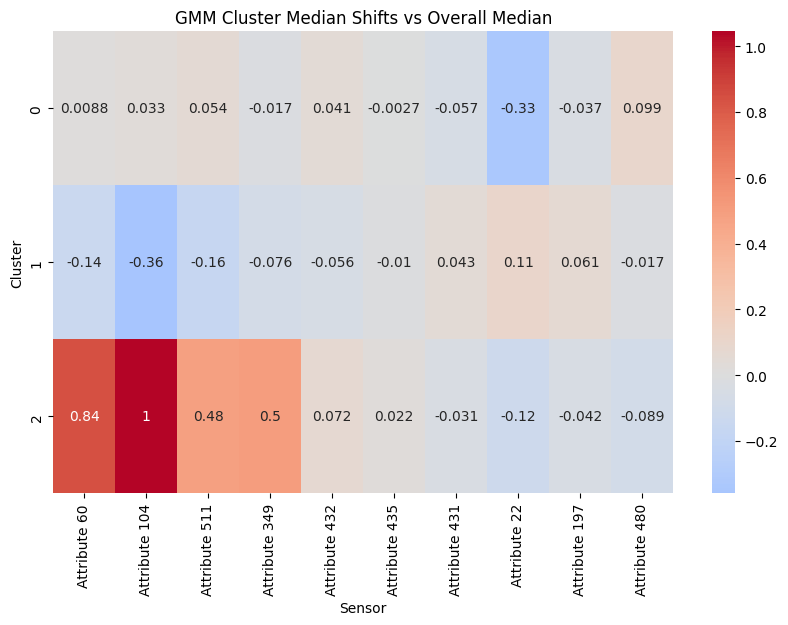

In [41]:
# Plotting the heatmap of the cluster median shifts per each sensor
plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_median_shift,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("GMM Cluster Median Shifts vs Overall Median")
plt.xlabel("Sensor")
plt.ylabel("Cluster")
plt.show()

In [42]:
# Merging risk_multiplier dataframe with cluster 2 median shift data
cluster_2 = cluster_median_shift.loc[2]
cluster_2 = cluster_2.reset_index()
cluster_2.columns = ["sensor", "cluster_2_shift"]
sensor_summary_final_df = top_sensor_summary_df.merge(cluster_2, how="left", on='sensor')
sensor_summary_final_df.sort_values("max_failure_rate", ascending=False)

,sensor,max_failure_rate,risk_multiplier,cluster_2_shift
3,Attribute 349,17.83,2.7,0.501261
0,Attribute 60,16.56,2.5,0.837124
2,Attribute 511,15.29,2.3,0.482575
1,Attribute 104,14.47,2.2,1.045193
4,Attribute 432,12.74,1.9,0.071879
7,Attribute 22,11.46,1.7,-0.116970
5,Attribute 435,10.19,1.5,0.021675
6,Attribute 431,10.19,1.5,-0.030738
8,Attribute 197,8.92,1.3,-0.042088
9,Attribute 480,8.28,1.2,-0.088996


#### Remarks: It appears there is some slight signal especially amongst sensors 60, 104, 511

Next Step: Correlation analysis amongst the sensors

___

### Correlation analysis
Running correlation analysis between sensors to drop redundant features

In [43]:
# running a correlation analysis to identify highly correlated features
corr = X_filtered.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "corr"]
pairs = pairs.sort_values(
    "corr",
    ascending=False
)

print(pairs.head(50))

            feature_1      feature_2      corr
32344    Attribute 75  Attribute 479  1.000000
133298  Attribute 343  Attribute 348  1.000000
89118   Attribute 210  Attribute 348  1.000000
89113   Attribute 210  Attribute 343  1.000000
89214   Attribute 210  Attribute 479  1.000000
32243    Attribute 75  Attribute 343  1.000000
32248    Attribute 75  Attribute 348  1.000000
32149    Attribute 75  Attribute 210  1.000000
135744  Attribute 348  Attribute 479  1.000000
87609   Attribute 207  Attribute 210  1.000000
87708   Attribute 207  Attribute 348  1.000000
87804   Attribute 207  Attribute 479  1.000000
32146    Attribute 75  Attribute 207  1.000000
87703   Attribute 207  Attribute 343  1.000000
133394  Attribute 343  Attribute 479  1.000000
15074    Attribute 35   Attribute 37  1.000000
62740   Attribute 141  Attribute 276  1.000000
75833   Attribute 173  Attribute 175  1.000000
121520  Attribute 308  Attribute 310  0.999999
67450   Attribute 153  Attribute 288  0.999997
99011   Attri

In [44]:
# examining the highly correlated feature pairs
high_corr = pairs[pairs["corr"] > 0.95]
high_corr.sort_values("corr", ascending=False).head(50)

,feature_1,feature_2,corr
32344,Attribute 75,Attribute 479,1.000000
133298,Attribute 343,Attribute 348,1.000000
89118,Attribute 210,Attribute 348,1.000000
89113,Attribute 210,Attribute 343,1.000000
89214,Attribute 210,Attribute 479,1.000000
32243,Attribute 75,Attribute 343,1.000000
32248,Attribute 75,Attribute 348,1.000000
32149,Attribute 75,Attribute 210,1.000000
135744,Attribute 348,Attribute 479,1.000000
87609,Attribute 207,Attribute 210,1.000000


In [45]:
# identifying columns to drop that are correlated more than 95%
to_drop = [
    col
    for col in upper.columns
    if any(upper[col] > 0.95)
]

print(f"Columns to drop: {len(to_drop)}")

Columns to drop: 186


In [46]:
# Checking to see if any of our top sensors are slated to be dropped
print("Top sensors to be dropped:", set(top_sensors).intersection(set(to_drop)))

Top sensors to be dropped: {'Attribute 480'}


In [47]:
# removing the columns correlated above threshold from the dataset
X_uncorr = X_filtered.drop(columns=to_drop)
X_uncorr.shape

(1567, 284)

In [48]:
# checking correlations with target
mi = mutual_info_classif(
    X_uncorr,
    y,
    random_state=42
)

mi = pd.Series(
    mi,
    index=X_uncorr.columns
)

mi.sort_values(
    ascending=False
).describe()

count    284.000000
mean       0.005453
std        0.006801
min        0.000000
25%        0.000000
50%        0.002307
75%        0.009740
max        0.026119
dtype: float64

In [49]:
# checking how many features have zero mutual info with target
(mi == 0).sum()

np.int64(108)

Text(0, 0.5, 'counts')

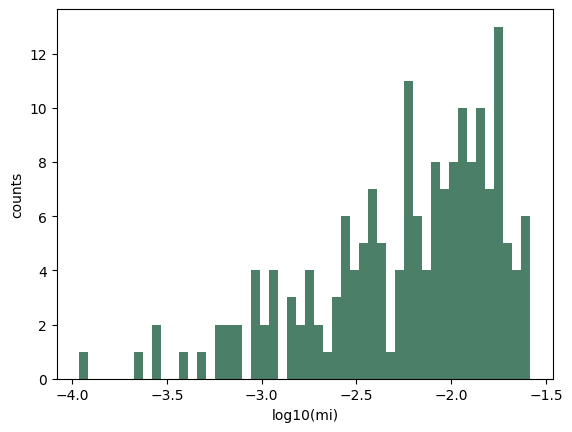

In [50]:
# plotting histogram of log mi to see distribution
plt.hist(np.log10(mi[mi > 0]), bins=50, color='#4B7F68')
plt.xlabel("log10(mi)")
plt.ylabel("counts")

___

### Final Remarks
Multiple exploratory analyses consistently identified a small subset of sensors (particularly Attributes 349, 60, 511, 104, and 432) as being associated with elevated failure risk. These sensors exhibit localized regions where failure probability increases by roughly 2–3× relative to the baseline 6.6% failure rate. However, no sensor provides clean class separation, and failures remain broadly distributed throughout sensor space. PCA, UMAP, t-SNE, Kernel PCA, and GMM analyses found no distinct failure cluster or low-dimensional manifold. The evidence suggests that failures arise from overlapping process regimes rather than a separate failure population, with risk increasing in specific regions of the sensor space.

1. classes highly imbalanced
2. Linear dimensionality reduction not resulting in class separation through various methods
3. Checking for nonlinear manifolds did not show obvious nonlinearity
4. Features highly correlated
5. No obvious variance cutoff after removing zero-variance features
6. Mutual information is not very high for any given sensor, will not use MI to exclude features

### Final Preprocessing Recommendation
1. Remove null features with > 90% nulls
2. Impute missing data with median
3. Remove zero-variance features
4. Drop columns with > 95% correlation

**Important:**
Correlation filtering and MI analysis were performed on the full dataset for exploratory purposes only.

Final modeling will implement these transformations inside a cross-validation pipeline to avoid data leakage.

### Modeling Suggestions
1. Try logistic regression with L1 regularization and inspect feature coefficients
2. Run XGBoost and compare performance gains with the linear models

